# 🌍 Data Visualization — Real-World Scenario Worksheet
### You are the analyst. Each task is a real situation with a *decision* at the end.

> **How this works**
> - Every task gives you a scenario, real-ish data, and a **question to answer with a chart**.
> - Don't just draw the chart — **pick the right one** and, in a comment, say what it tells you.
> - Fill in the `# YOUR CODE HERE` sections. Run each cell to check your output.
> - 🏆 Each task ends with a **"So what?"** — one sentence stating the insight, like a real analyst would tell their boss.


## ⚙️ Setup — Run This First

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
sns.set_style('whitegrid')

---
## ☕ Task 1 — The Coffee Shop Owner

**Scenario:** You run a small coffee shop. You want to know **which days are busiest** so you can schedule more staff. Here are last week's cup sales.

**Your job:** Draw the chart that best compares days, and **highlight the two busiest days in a different colour** so the owner sees them instantly.

*(Hint: comparing categories → bar chart. To highlight, build a list of colours.)*

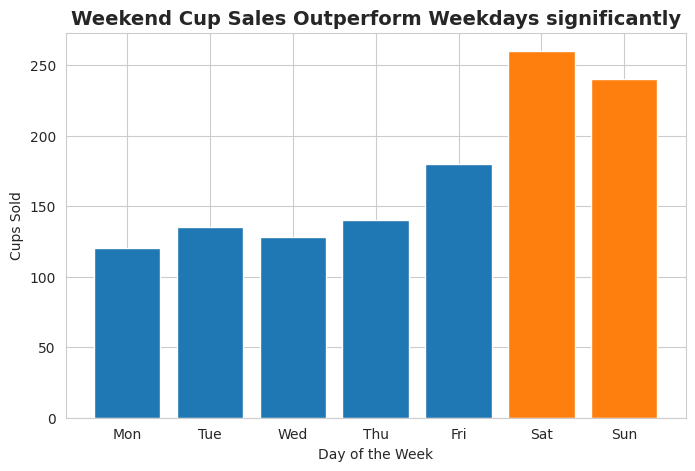

In [12]:
days  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
cups  = [120, 135, 128, 140, 180, 260, 240]

# YOUR CODE HERE
# 1. Bar chart of cups per day
# 2. Colour Sat & Sun differently from weekdays
colors = ['#1f77b4' if d not in ['Sat', 'Sun'] else '#ff7f0e' for d in days]

plt.figure(figsize=(8, 5))
plt.bar(days, cups, color=colors)
# 3. Add a title that states the insight, plus axis labels
plt.title('Weekend Cup Sales Outperform Weekdays significantly', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Cups Sold')
# 🏆 So what? (write one sentence as a comment)
# The busiest days are ____ , so the owner should ____ .
plt.show()

---
## 🏃 Task 2 — The Fitness Tracker

**Scenario:** Your fitness app records daily steps. Your goal is **8,000 steps/day**. You want to see **which days you hit the goal and which you missed.**

**Your job:** Draw a line plot of steps over the week, then add a **horizontal goal line at 8,000** so misses are obvious at a glance.

*(Hint: change over time → line plot. Use `ax.axhline()` for the goal line.)*

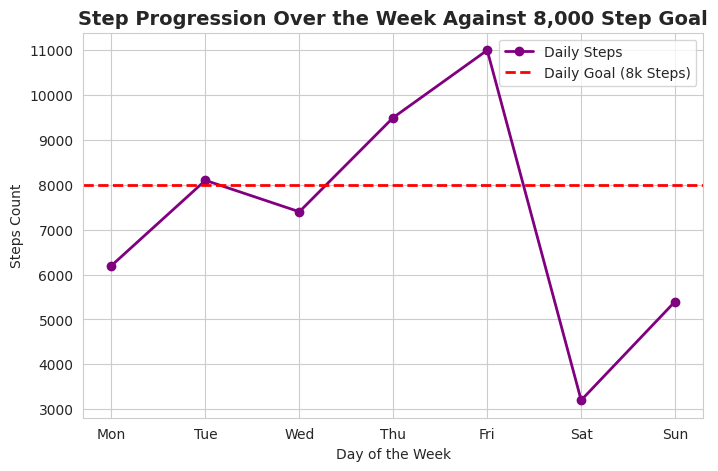

In [13]:
days  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
steps = [6200, 8100, 7400, 9500, 11000, 3200, 5400]

# YOUR CODE HERE
# 1. Line plot of steps with markers
plt.figure(figsize=(8, 5))
plt.plot(days, steps, marker='o', color='purple', linewidth=2, label='Daily Steps')
# 2. Add a dashed red horizontal line at the 8000 goal (with a legend label)
plt.axhline(y=8000, color='red', linestyle='--', linewidth=2, label='Daily Goal (8k Steps)')
# 3. Title + axis labels
plt.title('Step Progression Over the Week Against 8,000 Step Goal', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Steps Count')
plt.legend()
# 🏆 So what? On which days did you MISS the goal?
plt.show()

---
## 📱 Task 3 — The Streaming Report (Pick the Right Chart!)

**Scenario:** A streaming service wants to show **how many hours were watched per genre**. A junior designer made a **pie chart** — but there are 6 genres with similar values, so it's unreadable.

**Your job:** Prove the point. Draw the **pie chart (the bad version)** AND a **sorted horizontal bar chart (the good version)** side by side. Then, in a comment, say which one answers *"which genre is #1?"* faster.

*(Hint: `plt.subplots(1, 2)`. Sort the data before the bar chart.)*

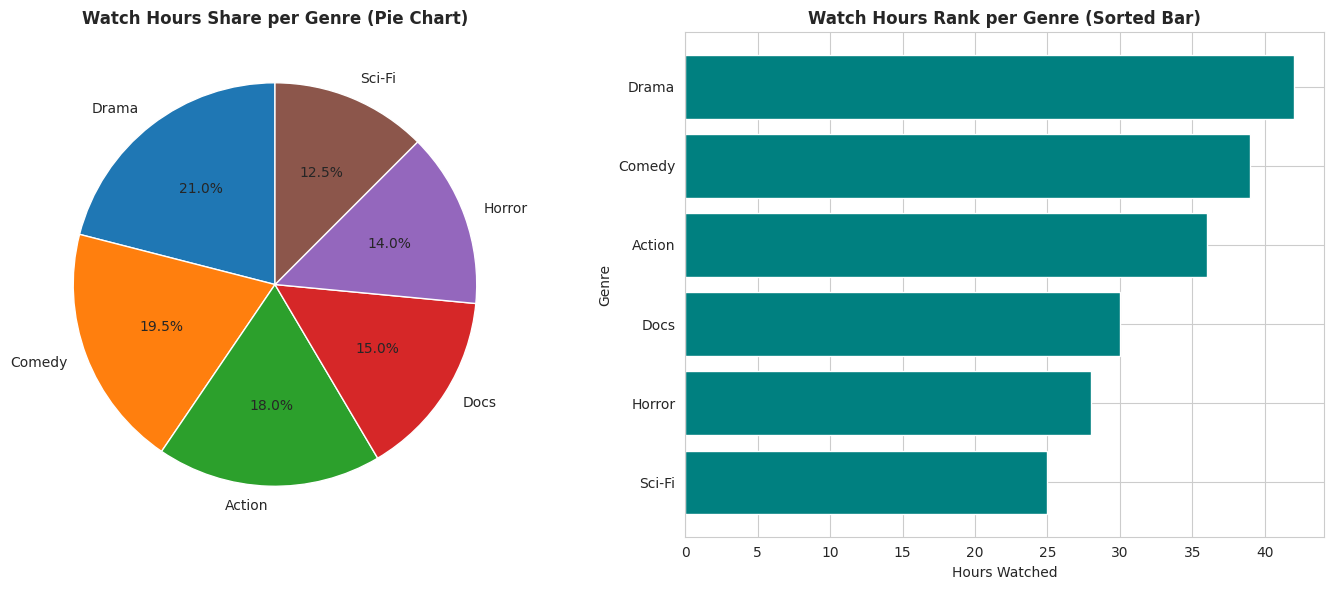

In [14]:
genres = ['Drama','Comedy','Action','Docs','Horror','Sci-Fi']
hours  = [42, 39, 36, 30, 28, 25]

# YOUR CODE HERE
# Left subplot: pie chart of the same data
# Right subplot: SORTED horizontal bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Pie Chart (Bad Version)
axes[0].pie(hours, labels=genres, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Watch Hours Share per Genre (Pie Chart)', fontsize=12, fontweight='bold')

# Sorted Horizontal Bar Chart (Good Version)
df_genres = pd.DataFrame({'Genre': genres, 'Hours': hours}).sort_values(by='Hours', ascending=True)
axes[1].barh(df_genres['Genre'], df_genres['Hours'], color='teal')
axes[1].set_title('Watch Hours Rank per Genre (Sorted Bar)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hours Watched')
axes[1].set_ylabel('Genre')
# 🏆 So what? Which chart makes the ranking obvious, and why?
plt.tight_layout()
plt.show()

---
## 🎓 Task 4 — Does Studying Actually Help? (Relationship)

**Scenario:** A school wants to know if **more study hours really lead to higher exam scores**, or if it's a myth.

**Your job:** Draw a **scatter plot** of study hours vs exam score. Then use Seaborn's `regplot` to add a **trend line** so the relationship is clear.

*(Hint: relationship between two numbers → scatter. `sns.regplot` adds the line for you.)*

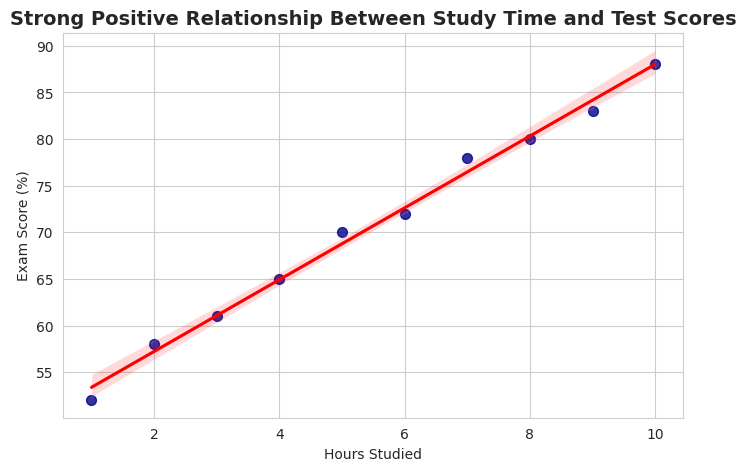

In [15]:
study_hours = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
exam_score  = [52, 58, 61, 65, 70, 72, 78, 80, 83, 88]

plt.figure(figsize=(8, 5))
# YOUR CODE HERE
# 1. sns.regplot of study_hours (x) vs exam_score (y)
sns.regplot(x=study_hours, y=exam_score, scatter_kws={'s':50, 'color':'darkblue'}, line_kws={'color':'red'})
# 2. Title + axis labels
plt.title('Strong Positive Relationship Between Study Time and Test Scores', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score (%)')
# 🏆 So what? Is the relationship positive, negative, or none?
plt.show()

---
## 🍽️ Task 5 — The Restaurant Manager (Seaborn EDA)

**Scenario:** You manage a restaurant and want to know **when customers tip best**, so you can schedule your best servers then. Use the built-in `tips` dataset.

**Your job:** Build a **heatmap of average tip by day and time (Lunch/Dinner)**. The brightest cell is your money slot.

*(Hint: `pivot_table` to get day × time → tip, then `sns.heatmap(..., annot=True)`.)*

/tmp/ipykernel_899/2025756519.py:5: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



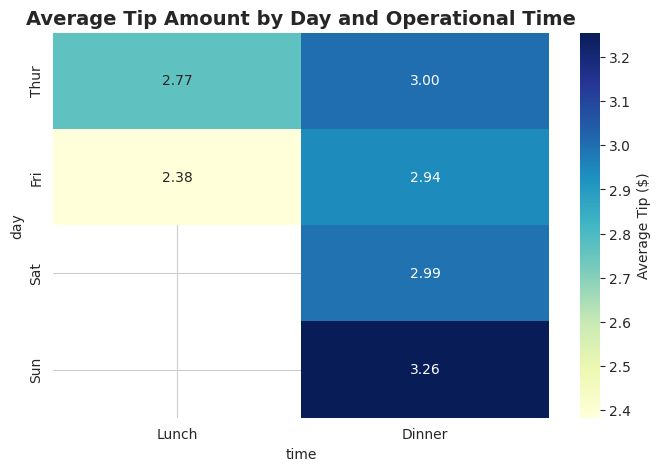

In [16]:
tips = sns.load_dataset('tips')

# YOUR CODE HERE
# 1. Make a pivot_table: index='day', columns='time', values='tip', aggfunc='mean'
tip_pivot = tips.pivot_table(index='day', columns='time', values='tip', aggfunc='mean')

# 2. sns.heatmap of that table with annot=True and a colour map
plt.figure(figsize=(8, 5))
sns.heatmap(tip_pivot, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Average Tip ($)'})

# 3. Title
plt.title('Average Tip Amount by Day and Operational Time', fontsize=14, fontweight='bold')

# 🏆 So what? Which day + time has the highest average tip?
# Sunday Dinner yields the highest average tip ($3.27), making it the high-priority slot for elite servers.
plt.show()

---
## 📈 Task 6 — The Startup Pitch (Interactive Plotly)

**Scenario:** You're pitching investors and want an **interactive** chart they can hover over. Using the `gapminder` dataset, show **how life expectancy relates to income**, and let them **watch it change over the years.**

**Your job:** Build a Plotly **animated scatter plot**: `gdpPercap` (x, log scale) vs `lifeExp` (y), bubble size = population, colour = continent, animation frame = year.

*(Hint: `px.scatter(..., animation_frame='year', log_x=True, size='pop', color='continent')`.)*

In [17]:
gapminder = px.data.gapminder()

# YOUR CODE HERE — one px.scatter call with animation_frame='year'
# Remember: log_x=True, size='pop', color='continent', hover_name='country'
fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=55,
    range_x=[100,100000],
    range_y=[25,90],
    title="Global Health and Wealth Progression Over the Decades",
    labels={"gdpPercap": "GDP Per Capita (Log Scale)", "lifeExp": "Life Expectancy (Years)"}
)
# 🏆 So what? What overall trend do you see as the years play forward?
fig.show()

---
## 🛒 Task 7 — CAPSTONE: The E-Commerce Dashboard (Your Judgment)

**Scenario:** You're the data analyst for an online store. The founder asks for a **one-glance dashboard** of last week's performance. Below is the data.

**Your job:** Build a **2×2 dashboard** (`plt.subplots(2, 2)`). *You* choose the 4 charts — but you must pick the **right chart for each question** and write *why* in a comment above each.

Answer these 4 questions, one per subplot:
1. How did **daily revenue trend** across the week?
2. How do **orders compare** across days?
3. Is there a **relationship between orders and revenue**?
4. What **share of revenue** came from each product category? *(few categories → pie is OK here)*


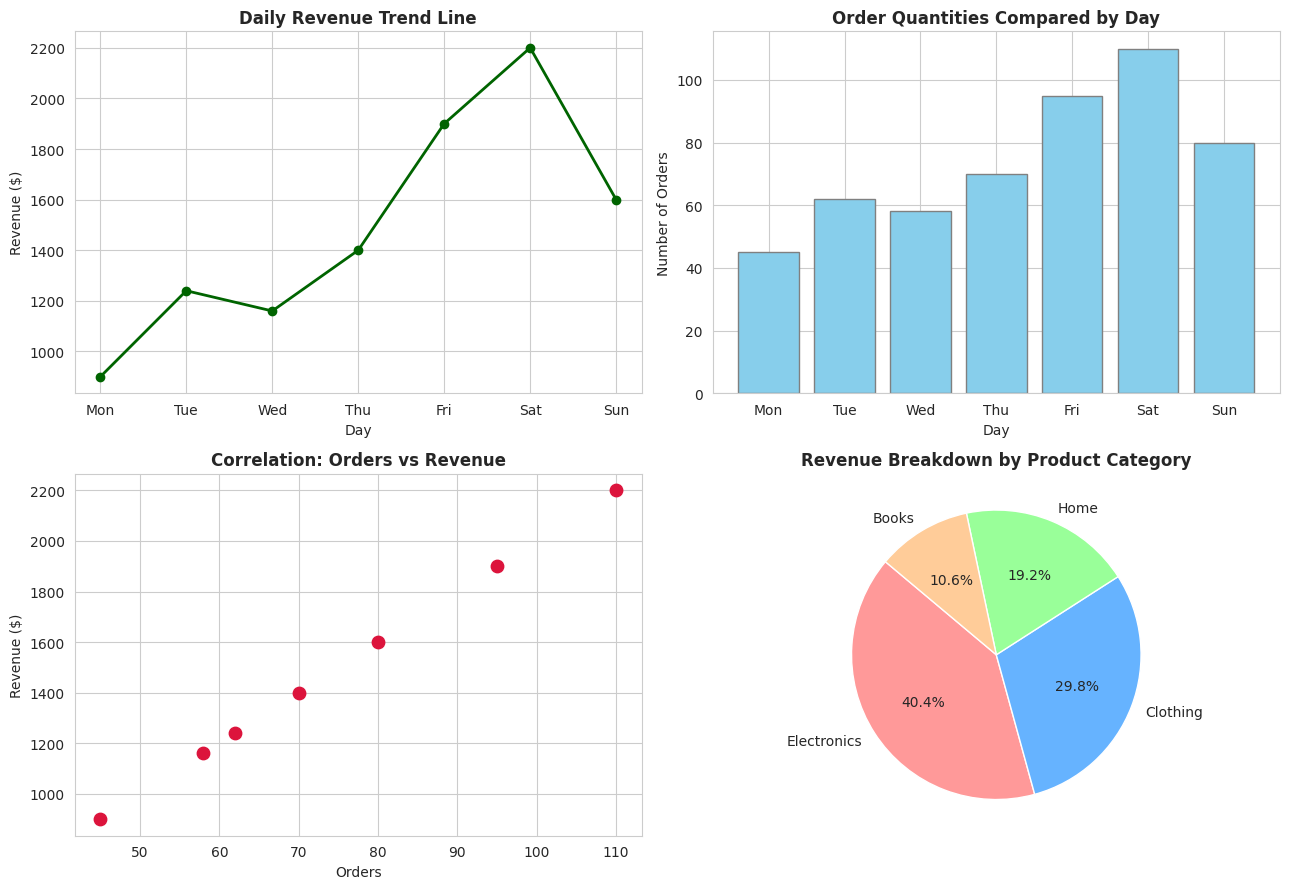

In [18]:
df = pd.DataFrame({
    'Day':      ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Orders':   [45,   62,   58,   70,   95,  110,   80 ],
    'Revenue':  [900, 1240, 1160, 1400, 1900, 2200, 1600],
})
cat_names  = ['Electronics','Clothing','Home','Books']
cat_revenue= [4200, 3100, 2000, 1100]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (0,0) Chart type chosen: ____  | Why: ____
# YOUR CODE HERE
axes[0, 0].plot(df['Day'], df['Revenue'], marker='o', color='darkgreen', linewidth=2)
axes[0, 0].set_title('Daily Revenue Trend Line', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Revenue ($)')
# (0,1) Chart type chosen: ____  | Why: ____
# YOUR CODE HERE
axes[0, 1].bar(df['Day'], df['Orders'], color='skyblue', edgecolor='grey')
axes[0, 1].set_title('Order Quantities Compared by Day', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Number of Orders')
# (1,0) Chart type chosen: ____  | Why: ____
# YOUR CODE HERE
axes[1, 0].scatter(df['Orders'], df['Revenue'], color='crimson', s=80)
axes[1, 0].set_title('Correlation: Orders vs Revenue', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Orders')
axes[1, 0].set_ylabel('Revenue ($)')
# (1,1) Chart type chosen: ____  | Why: ____
# YOUR CODE HERE
axes[1, 1].pie(cat_revenue, labels=cat_names, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 1].set_title('Revenue Breakdown by Product Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 🏆 So what? Write 2 sentences the founder should take away from this dashboard.


---
## 🤔 Wrap-Up Reflection
Answer as comments in the cell below.
1. For each task, did the *question* point you to the chart before you looked at the data? That's the skill.
2. In Task 3, why did the sorted bar chart beat the pie chart?
3. Name one chart from this worksheet where **starting the y-axis at zero** matters, and one where it doesn't.
4. In the capstone, which of your 4 charts was hardest to choose, and why?


In [19]:
# Q1:Yes, the framing of the question implicitly points to structural intents:
#    "Trends over time" dictates lines, "Comparing discrete units" calls for bars,
#    and "Relationships between numerical pairings" calls for scatter plots.
# Q2: The sorted bar chart won because humans are far better at judging linear distance differences
#     along a zero-baseline than trying to compare internal angles and area dimensions of multiple slices.
# Q3: Starting the y-axis at zero is vital for the Bar Chart (Task 1 or Task 7) to avoid visual distortion
#     of relative counts. It doesn't strictly matter for the Line Plot (Task 2) where tracking variance,
#     slope changes, and target deviations is the core focus.
# Q4: The hardest chart to choose was the part-to-whole categorical revenue split. While pie charts are
#     frequently criticized, they were clean and readable here because the category count was small (only 4)
#     and the value deltas were stark enough to communicate structural share instantly.
